/tmp/ipykernel_7838/2774086033.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([str(int(abs(tick))) for tick in ticks])


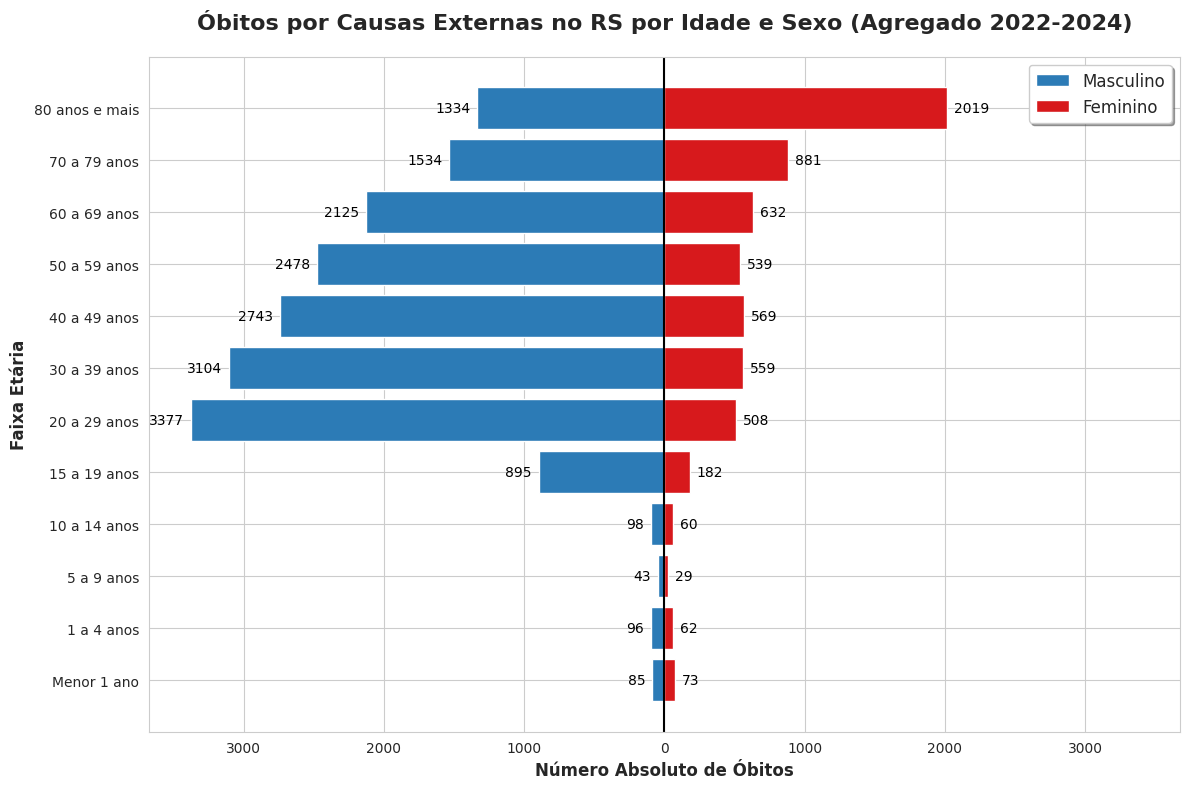

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento e Preparação dos Dados
arquivos = ['mortalidade_2022.csv', 'mortalidade_2023.csv', 'mortalidade_2024.csv']
idades_validas = [
    'Menor 1 ano', '1 a 4 anos', '5 a 9 anos', '10 a 14 anos', '15 a 19 anos',
    '20 a 29 anos', '30 a 39 anos', '40 a 49 anos', '50 a 59 anos',
    '60 a 69 anos', '70 a 79 anos', '80 anos e mais'
]

dataframes = []
for arquivo in arquivos:
    # Ignorando as linhas iniciais de cabeçalho do TABNET (skiprows=4)
    try:
        df = pd.read_csv(arquivo, sep=';', skiprows=4, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(arquivo, sep=';', skiprows=4, engine='python', encoding='latin-1')
    dataframes.append(df)

# Unindo os 3 anos em um único DataFrame
df_total = pd.concat(dataframes, ignore_index=True)

# Filtrando apenas as linhas que correspondem a faixas etárias reais (removendo rodapés/totais)
df_limpo = df_total[df_total['Faixa Etária'].isin(idades_validas)].copy()

# Tratando os dados: substituindo '-' por 0 e garantindo que são numéricos
for col in ['Masc', 'Fem']:
    df_limpo[col] = df_limpo[col].replace('-', 0)
    df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce').fillna(0)

# Agrupando pelo total dos 3 anos
df_agrupado = df_limpo.groupby('Faixa Etária')[['Masc', 'Fem']].sum().reset_index()

# Ordenando as faixas etárias logicamente
df_agrupado['Faixa Etária'] = pd.Categorical(df_agrupado['Faixa Etária'], categories=idades_validas, ordered=True)
df_agrupado = df_agrupado.sort_values('Faixa Etária')


# 2. Visualização (Codificação Visual de Alta Qualidade)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Para o efeito de "pirâmide", invertemos o sinal dos dados masculinos
homens = df_agrupado['Masc'] * -1
mulheres = df_agrupado['Fem']
y_pos = df_agrupado['Faixa Etária']

# Desenhando as barras
barras_m = plt.barh(y_pos, homens, color='#2c7bb6', edgecolor='white', label='Masculino')
barras_f = plt.barh(y_pos, mulheres, color='#d7191c', edgecolor='white', label='Feminino')

# Ajustando o eixo X para mostrar valores absolutos (positivos em ambos os lados)
max_val = max(homens.abs().max(), mulheres.max()) + 300
plt.xlim(-max_val, max_val)

ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([str(int(abs(tick))) for tick in ticks])

# Embelezamento do gráfico
plt.title('Óbitos por Causas Externas no RS por Idade e Sexo (Agregado 2022-2024)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Número Absoluto de Óbitos', fontsize=12, weight='bold')
plt.ylabel('Faixa Etária', fontsize=12, weight='bold')
plt.axvline(0, color='black', linewidth=1.5) # Linha central separadora
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

# Adicionando os rótulos de dados (valores em texto ao lado de cada barra)
for bar in barras_m:
    width = bar.get_width()
    if width < 0: # Evita adicionar zero
        plt.text(width - 50, bar.get_y() + bar.get_height()/2, f'{int(abs(width))}',
                 va='center', ha='right', color='black', fontsize=10)

for bar in barras_f:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 50, bar.get_y() + bar.get_height()/2, f'{int(width)}',
                 va='center', ha='left', color='black', fontsize=10)

plt.tight_layout()
plt.show()

O gráfico de barras divergentes acima apresenta a totalidade de mortalidade decorrentes de causas externas (Capítulo XX do CID-10) ocorridos no Rio Grande do Sul entre os anos de 2022 e 2024, subdivididos por sexo e faixa etária.

Observa-se uma disparidade de mortalidade entre os gêneros na fase de juventude e vida adulta (especialmente entre 20 e 39 anos), onde a mortalidade masculina é superior à feminina. Este padrão comportamental reflete a maior exposição histórica de homens jovens à violência urbana e acidentes de trânsito.